# SILVA SNARF Forward Skinning

This lab derives canonical blend weights, forward deformation, multi-start
implicit correspondences, occupancy composition, and the route to mesh-scale
experiments. The mechanism follows SNARF [[62]](https://jseluis.github.io/silva-networks/paper/references/#ref-62) and uses SILVA's configurable
root solver without hiding the geometric fields.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[62]](https://jseluis.github.io/silva-networks/paper/references/#ref-62), [[68]](https://jseluis.github.io/silva-networks/paper/references/#ref-68), [[69]](https://jseluis.github.io/silva-networks/paper/references/#ref-69), [[70]](https://jseluis.github.io/silva-networks/paper/references/#ref-70), [[71]](https://jseluis.github.io/silva-networks/paper/references/#ref-71). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(33)

from torch import nn
from silva_networks import (
    SILVASNARF,
    SolverConfig,
    make_snarf_stick_dataset,
    silva_forward_skinning,
)

## 1. Forward Skinning Is the Model

Canonical weights obey $w_b(x)\geq0$ and $\sum_bw_b(x)=1$. Bone transforms
produce

$$d_w(x,B)=\sum_bw_b(x)B_b\bar x.$$

Unlike a pose-dependent backward field, $w(x)$ lives in canonical space. The
compact two-bone stick supplies known weights and deformed points.

In [3]:
data = make_snarf_stick_dataset(points=61)
reconstructed = silva_forward_skinning(
    data.canonical_points, data.transforms, data.blend_weights
)
assert torch.allclose(reconstructed, data.deformed_points)
print("points/bones:", data.canonical_points.shape[0], data.transforms.shape[0])
print("forward error:", float((reconstructed - data.deformed_points).abs().max()))

points/bones: 61 2
forward error: 0.0


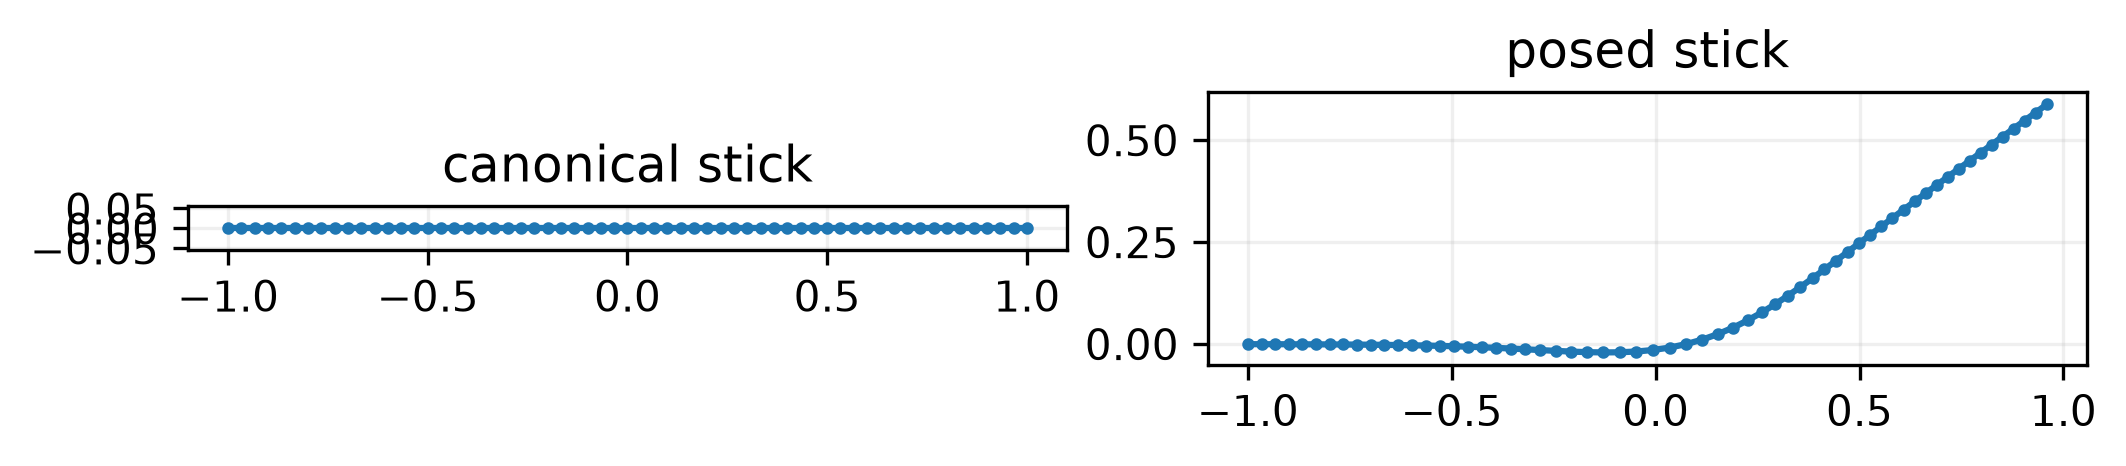

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(7.2, 2.8))
axes[0].plot(data.canonical_points[:, 0], data.canonical_points[:, 1], "o-", ms=2)
axes[0].set(title="canonical stick", aspect="equal")
axes[1].plot(data.deformed_points[:, 0], data.deformed_points[:, 1], "o-", ms=2)
axes[1].set(title="posed stick", aspect="equal")
for axis in axes:
    axis.grid(alpha=0.2)
figure.tight_layout()
plt.show()

## 2. Canonical Correspondences as Roots

For posed query $x'$, each canonical correspondence satisfies

$$d_w(x^\star,B)-x'=0.$$

Every inverse bone transform supplies a starting point
$x_b^0=B_b^{-1}\bar x'$. Multiple valid roots are retained because folds and
self-contact can make the inverse one-to-many.

In [5]:
class ExactStickWeights(nn.Module):
    def forward(self, points):
        left = torch.sigmoid(-8.0 * points[..., 0])
        return torch.stack([left, 1.0 - left], dim=-1)

class StickOccupancy(nn.Module):
    def forward(self, points, pose=None):
        return torch.sigmoid(20.0 * (0.12 - points[..., 1].abs())).unsqueeze(-1)

model = SILVASNARF(
    coordinate_dim=2,
    bones=2,
    weight_field=ExactStickWeights(),
    occupancy_field=StickOccupancy(),
    correspondence_tol=2e-3,
    config=SolverConfig(
        solver="broyden",
        max_iter=35,
        tol=1e-7,
        history=8,
        backward_mode="unrolled",
        return_best=True,
    ),
)
result = model(data.deformed_points, data.transforms, return_result=True)
best_residual = result.residuals.min(dim=1).values
assert best_residual.max() < 2e-3
print("valid candidates:", int(result.valid.sum()), "/", result.valid.numel())
print("maximum best-root residual:", float(best_residual.max()))
print("occupancy range:", float(result.occupancy.min()), float(result.occupancy.max()))

valid candidates: 122 / 122
maximum best-root residual: 3.332000986233652e-08
occupancy range: 0.9168272614479065 0.9168273210525513


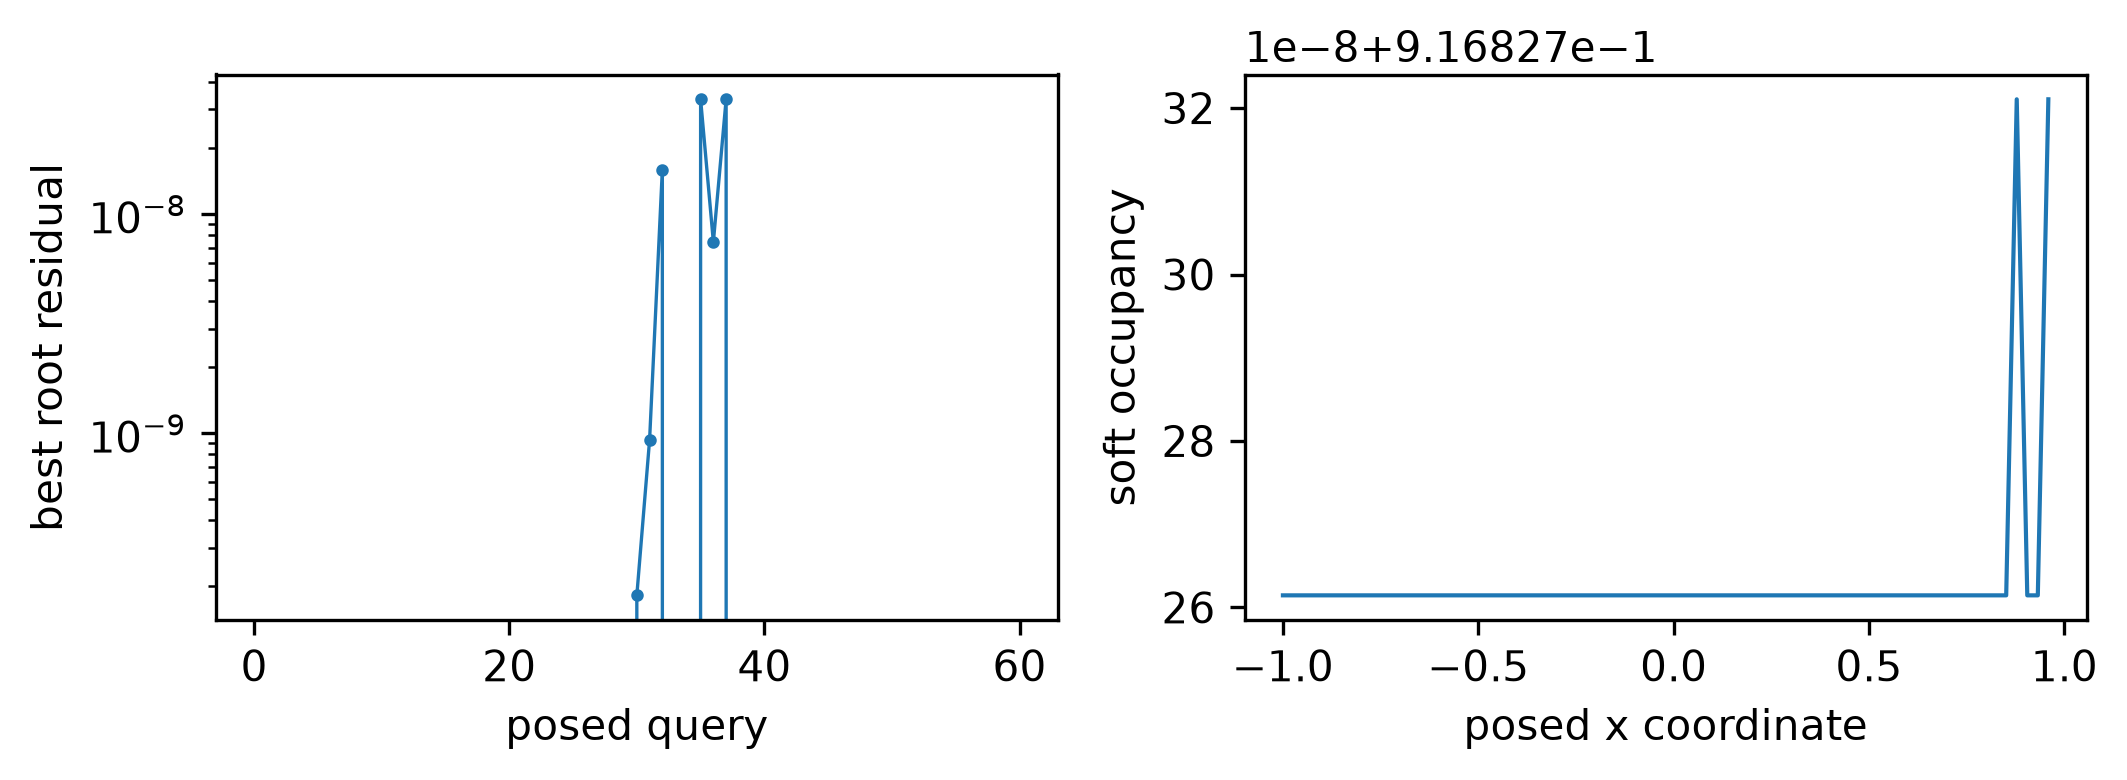

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(7.2, 2.7))
axes[0].semilogy(best_residual.detach(), marker="o", ms=2, lw=0.8)
axes[0].set(xlabel="posed query", ylabel="best root residual")
axes[1].plot(data.deformed_points[:, 0], result.occupancy.detach(), lw=1)
axes[1].set(xlabel="posed x coordinate", ylabel="soft occupancy")
figure.tight_layout()
plt.show()

## 3. What the Advanced User Replaces

`weight_field` maps arbitrary leading point dimensions to simplex-valued bone
weights. `occupancy_field` maps canonical points and optional pose to occupancy.
The transform count, root solver, residual threshold, and soft-union temperature
are independent. `sample_occupancy_grid` evaluates the posed field in chunks;
its output can be passed to marching cubes when a mesh is required.

## 4. Source-Scale Route

For 2D Stick, match the source canonical geometry, topology-change object,
poses, query distribution, and occupancy labels. For human experiments, obtain
the required DFaust/AMASS or CAPE data under their terms, reproduce subject and
sequence splits, bone transforms, canonical pose, 20K-point frame sampling,
near-surface noise, bootstrap losses, and unseen-pose metrics. Store source
archive checksums and mesh preprocessing. Large human-motion collections and
derived meshes may require substantial local storage; inspect the selected
dataset release before acquisition instead of assuming one fixed size.

## Source Data and Full Experiment Preflight

Use the unrestricted articulated-stick case first. Full experiments follow the source preprocessing [[62]](https://jseluis.github.io/silva-networks/paper/references/#ref-62) and separately licensed AMASS [[68]](https://jseluis.github.io/silva-networks/paper/references/#ref-68), D-FAUST [[69]](https://jseluis.github.io/silva-networks/paper/references/#ref-69), CAPE [[70]](https://jseluis.github.io/silva-networks/paper/references/#ref-70), and SMPL [[71]](https://jseluis.github.io/silva-networks/paper/references/#ref-71) assets. Preflight one subject and a few frames before the complete sequence protocol.

The executable record below distinguishes public, generated, and licensed
inputs and keeps storage and launch steps next to the model contract. Compact
results validate the implementation route; the cited benchmark additionally
requires every recorded source-scale step.

In [7]:
from silva_networks import silva_reproduction_spec

source_plan = silva_reproduction_spec('silva_snarf')
print("data sources:")
for source in source_plan.data_sources:
    print(" -", source)
print("access:")
for item in source_plan.data_access:
    print(" -", item)
print("storage:")
for item in source_plan.storage_plan:
    print(" -", item)
print("source-scale steps:")
for index, item in enumerate(source_plan.source_scale_steps, start=1):
    print(f" {index}. {item}")

data sources:
 - https://github.com/xuchen-ethz/snarf
 - https://amass.is.tue.mpg.de/
 - https://dfaust.is.tue.mpg.de/
 - https://cape.is.tue.mpg.de/
 - https://smpl.is.tue.mpg.de/
access:
 - The implementation and test assets are public, while SMPL, AMASS, D-FAUST, and CAPE require their own registrations or licenses.
 - Keep raw licenses outside package artifacts and record the exact subject, sequence, clothing, and preprocessing revision.
storage:
 - Budget raw meshes and motion separately from sampled occupancy/query tensors.
 - Query-cache bytes scale with frames * samples per frame * (coordinates + occupancy + optional skinning labels) * bytes per value.
source-scale steps:
 1. Acquire the permitted SMPL and motion/mesh assets and run the source point-sampling preprocessing for a declared subject split.
 2. Train canonical blend weights and occupancy with inverse-bone starts, Broyden roots, residual filtering, and pose conditioning.
 3. Evaluate within-distribution and unseen pos

## From 31 Silva Snarf Forward Skinning to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | one latent feature vector per coordinate |
| Condition | spatial, temporal, or spatiotemporal coordinates |
| Repeated computation | a coordinate-injected recurrent field |
| Required invariants | coordinate shape, output domain, differentiability, and state width |
| Replaceable components | coordinate lift, recurrent transition, activation, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace Every Forward-Deformation Component

```python
model = SILVASNARF(
    weight_field=my_canonical_blend_weights,
    occupancy_field=my_canonical_occupancy,
    transforms=my_bone_transforms,
    root_solver="broyden",
    root_initializers=my_inverse_bone_initializers,
)
```

Blend weights live in canonical space, forward skinning maps candidates to the
posed observation, and occupancy is evaluated only after root recovery. A full
reproduction should preserve multiple initializations, root filtering, soft
union, pose splits, occupancy sampling, and mesh-extraction settings.


In [8]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**signal error, coordinate-derivative error, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **sample count, coordinate dimension, frequency scale, and hidden width**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [9]:
notebook_reproduction_record = {
    "notebook": '31_silva_snarf_forward_skinning.ipynb',
    "state": 'one latent feature vector per coordinate',
    "condition": 'spatial, temporal, or spatiotemporal coordinates',
    "transition": 'a coordinate-injected recurrent field',
    "invariants": 'coordinate shape, output domain, differentiability, and state width',
    "compact_metric": 'signal error, coordinate-derivative error, and fixed-point residual',
    "scale_axis": 'sample count, coordinate dimension, frequency scale, and hidden width',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '31_silva_snarf_forward_skinning.ipynb',
 'state': 'one latent feature vector per coordinate',
 'condition': 'spatial, temporal, or spatiotemporal coordinates',
 'transition': 'a coordinate-injected recurrent field',
 'invariants': 'coordinate shape, output domain, differentiability, and state width',
 'compact_metric': 'signal error, coordinate-derivative error, and fixed-point residual',
 'scale_axis': 'sample count, coordinate dimension, frequency scale, and hidden width'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **transition feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **one latent feature vector per coordinate**, and its repeated map,
**a coordinate-injected recurrent field**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [10]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('transition feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


transition feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


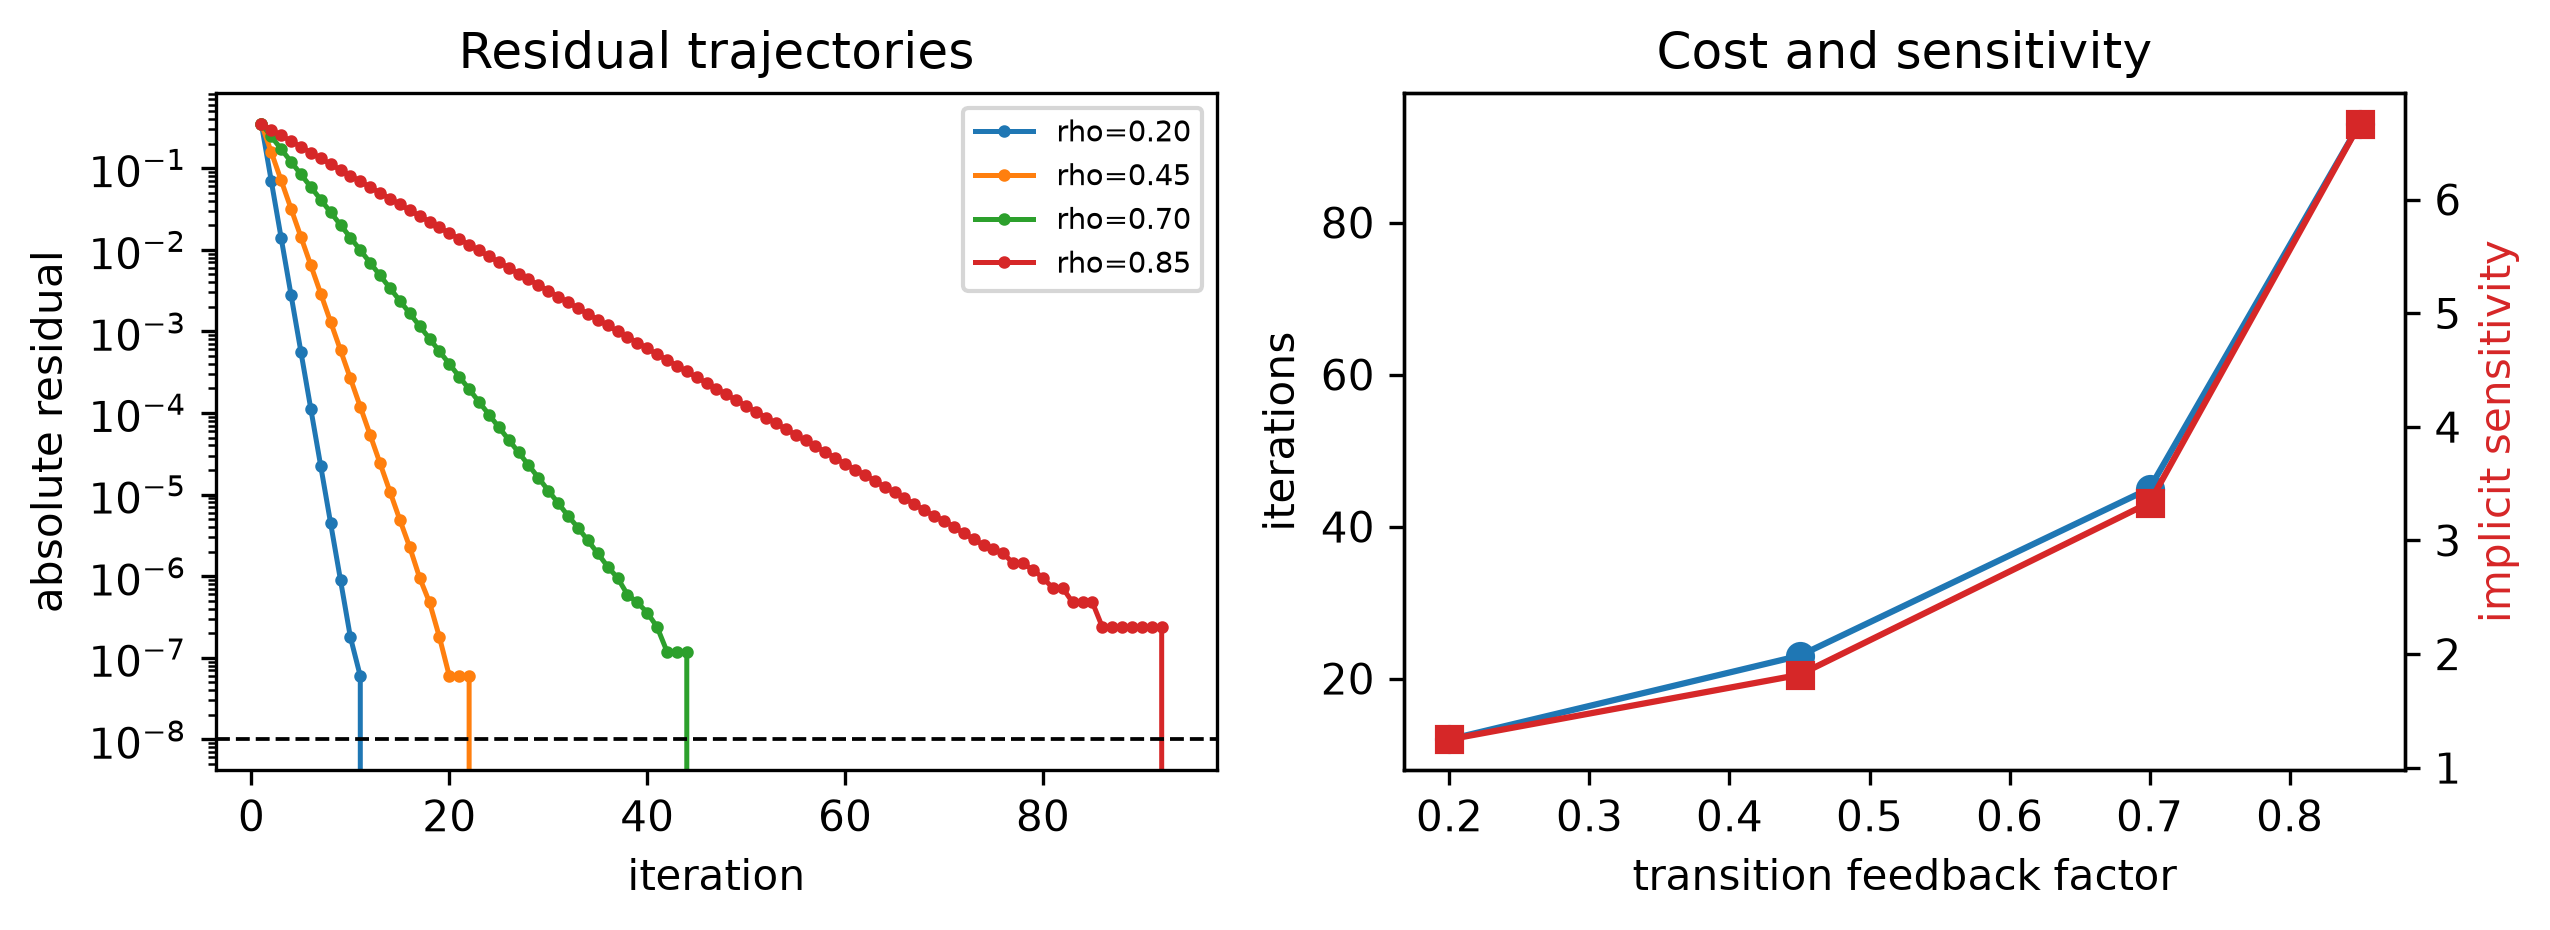

In [11]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('transition feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the transition feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | signal error, coordinate-derivative error, and fixed-point residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | coordinate shape, output domain, differentiability, and state width |
| Scale sweep | Change one of sample count, coordinate dimension, frequency scale, and hidden width at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How does forward skinning become a multi-root SILVA problem? | [Emerging Equilibrium Methods](https://jseluis.github.io/silva-networks/learn/emerging-equilibrium-methods/#snarf-style-forward-skinning) |
| Which deformation, occupancy, and root APIs are public? | [Emerging Equilibria API](https://jseluis.github.io/silva-networks/api/emerging_equilibria/) |
| Which compact posed-space data checks inverse recovery? | [Emerging Data API](https://jseluis.github.io/silva-networks/api/emerging_data/) |
